<a href="https://colab.research.google.com/github/Qophy/PBML/blob/main/Copy_of_Copy_4_of_Model_1_00.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import tensorflow as tf
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [ ]:
raw_data = pd.read_csv('/content/drive/MyDrive/PINN_WQS_dataset/wq_dataset_node_cycles_1.csv')

In [ ]:
raw_data.sample(5)

,Temperature,Conductivity,pH,hour_sin,hour_cos,DOW_sin,DOW_cos,Mon_sin,Mon_cos
3240,25.26,616.3,7.09,-5.000000e-01,0.866025,0.974928,-0.222521,-5.000000e-01,-8.660254e-01
13111,13.22,286.3,0.29,1.224647e-16,-1.000000,0.974928,-0.222521,-8.660254e-01,5.000000e-01
8696,18.34,326.8,2.65,5.000000e-01,0.866025,-0.974928,-0.222521,-1.000000e+00,-1.836970e-16
9640,15.22,335.1,1.67,9.659258e-01,-0.258819,-0.781831,0.623490,-1.000000e+00,-1.836970e-16
833,18.22,330.2,8.03,7.071068e-01,-0.707107,0.433884,-0.900969,1.224647e-16,-1.000000e+00


In [ ]:
def scale_raw_data(df, scalar=None):
  df = df.copy()
  if not scalar:
    scaler = StandardScaler()
    scaled_dataset = scaler.fit_transform(df)
  else:
    scaled_dataset = scaler.fit_transform(df)

  return scaled_dataset, scaler

In [ ]:
# separate inputs and targets
time_var = raw_data[["hour_sin", "hour_cos", "DOW_sin", "DOW_cos", "Mon_sin", "Mon_cos"]].values

env_vars =  raw_data[["Temperature"]].values

targets =  raw_data[["Conductivity", "pH"]].values

In [ ]:
time_var_scaled, time_var_scaler = scale_raw_data(time_var)
#time_var_scaled = time_var
env_vars_scaled, env_vars_scaler = scale_raw_data(env_vars)
targets_scaled, targets_scaler = scale_raw_data(targets)

In [ ]:
(
    t_train, t_test,
    env_train, env_test,
    y_train, y_test
) = train_test_split(time_var_scaled, env_vars_scaled, targets_scaled, test_size=0.2, random_state=42)

In [ ]:
batch_size = 32

train_dataset = (
    tf.data.Dataset.from_tensor_slices(((t_train, env_train), y_train))
    .batch(batch_size)
    .prefetch(tf.data.AUTOTUNE)
)
#.shuffle(buffer_size=len(t_train))  # ✅ shuffle training only

test_dataset = (
    tf.data.Dataset.from_tensor_slices(((t_test, env_test), y_test))
    .batch(batch_size)  # ❌ no shuffle here
    .prefetch(tf.data.AUTOTUNE)
)

In [ ]:
class SelfAttentionBlock(tf.keras.layers.Layer):

    def __init__(self, d_model, num_heads=4, key_dim=32):
        super().__init__()

        # Separate attention for time and environment
        self.mha_time = tf.keras.layers.MultiHeadAttention(
            num_heads=num_heads,
            key_dim=key_dim
        )

        self.mha_env = tf.keras.layers.MultiHeadAttention(
            num_heads=num_heads,
            key_dim=key_dim
        )

        # Output projections
        self.out_time = tf.keras.layers.Dense(d_model)
        self.out_env  = tf.keras.layers.Dense(d_model)

        # Final fusion layer
        self.fusion = tf.keras.layers.Dense(d_model)

    def call(self, inputs):
        # Unpack inputs
        t, env = inputs

        # Expand dims → treat features as tokens
        t = tf.expand_dims(t, axis=-1)     # (batch, t_features, 1)
        env = tf.expand_dims(env, axis=-1) # (batch, env_features, 1)

        # Self-attention separately
        h_t = self.mha_time(query=t, key=t, value=t)
        h_e = self.mha_env(query=env, key=env, value=env)

        # Project
        h_t = self.out_time(h_t)
        h_e = self.out_env(h_e)

        # Pool (compress tokens)
        h_t = tf.reduce_mean(h_t, axis=1)  # (batch, d_model)
        h_e = tf.reduce_mean(h_e, axis=1)  # (batch, d_model)

        # Combine both representations
        h = tf.concat([h_t, h_e], axis=-1)

        # Final fusion
        h = self.fusion(h)

        return h

In [ ]:
def build_nn_branch():

    return tf.keras.Sequential([
        tf.keras.layers.Dense(32, activation="tanh"),
        tf.keras.layers.Dense(32, activation="tanh"),
        tf.keras.layers.Dense(32, activation="tanh"),
        tf.keras.layers.Dense(1)
    ])

In [ ]:
def build_interaction_module():

    return tf.keras.Sequential([
        tf.keras.layers.Dense(32, activation="tanh"),
        tf.keras.layers.Dense(32, activation="tanh"),
        tf.keras.layers.Dense(32, activation="tanh")
    ])

In [ ]:
class ParallelAttentionInteractionModel(tf.keras.Model):

    def __init__(self, n_targets=2, d_model=32):

        super().__init__()

        self.n_targets = n_targets

        # Parallel attention modules
        self.attention_blocks = [
            SelfAttentionBlock(d_model)
            for _ in range(n_targets)
        ]

        # Parallel NN branches
        self.nn_branches = [
            build_nn_branch()
            for _ in range(n_targets)
        ]

        # Interaction module
        self.interaction = build_interaction_module()

        # Final output heads
        self.output_heads = [
            tf.keras.layers.Dense(1)
            for _ in range(n_targets)
        ]


    def call(self, inputs):

        time_var, env_vars = inputs

        # Parallel SA + NN branches
        phi_list = []

        for sa, nn in zip(self.attention_blocks, self.nn_branches):

            h = sa((time_var, env_vars)) # Pass as tuple
            phi = nn(h)

            phi_list.append(phi)

        # Level-1 predictions
        phi_L1 = tf.concat(phi_list, axis=-1)

        # Interaction module
        h_interact = self.interaction(phi_L1)

        # Level-2 predictions
        outputs = []

        for head in self.output_heads:

            outputs.append(head(h_interact))

        phi_L2 = tf.concat(outputs, axis=-1)

        return phi_L2

In [ ]:
n_targets=2
model = ParallelAttentionInteractionModel(n_targets=n_targets)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="mse",
    metrics=["mae"]
)

history = model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=50
)

Epoch 1/50
461/461 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - loss: 0.5748 - mae: 0.5522 - val_loss: 0.5324 - val_mae: 0.5290
Epoch 2/50
461/461 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - loss: 0.4938 - mae: 0.5107 - val_loss: 0.4815 - val_mae: 0.5007
Epoch 3/50
461/461 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - loss: 0.4625 - mae: 0.4920 - val_loss: 0.4654 - val_mae: 0.4904
Epoch 4/50
461/461 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - loss: 0.4479 - mae: 0.4842 - val_loss: 0.4572 - val_mae: 0.4861
Epoch 5/50
461/461 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 0.4376 - mae: 0.4782 - val_loss: 0.4426 - val_mae: 0.4771
Epoch 6/50
461/461 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - loss: 0.4290 - mae: 0.4715 - val_loss: 0.4319 - val_mae: 0.4687
Epoch 7/50
461/461 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 0.4223 - mae: 0.4657 - val_loss: 0.4235 - val_mae: 0.4616
Epoch 8/50
461/461 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - loss: 0.4162 - mae: 0.4604 - val_loss: 0.4153 - val_mae: 0.4560
Epoch 9/50
461/461 ━━━━━━━━━━━━━━━━━━━━ 5s 12m

In [ ]:
n_targets=2
model = ParallelAttentionInteractionModel(n_targets=n_targets)

# Define the learning rate schedule
initial_learning_rate = 1e-3
lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate,
    decay_steps=10000,
    decay_rate=0.9,
    staircase=True)

# Create an optimizer with the learning rate schedule
optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)

model.compile(
    optimizer=optimizer,
    loss="mse",
    metrics=["mae"]
)

history = model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=200
)

Epoch 1/200
461/461 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - loss: 0.8708 - mae: 0.7200 - val_loss: 0.7027 - val_mae: 0.6543
Epoch 2/200
461/461 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - loss: 0.6531 - mae: 0.6122 - val_loss: 0.6483 - val_mae: 0.6070
Epoch 3/200
461/461 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.6335 - mae: 0.5961 - val_loss: 0.6458 - val_mae: 0.6070
Epoch 4/200
461/461 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.6261 - mae: 0.5907 - val_loss: 0.6405 - val_mae: 0.6021
Epoch 5/200
461/461 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.6220 - mae: 0.5878 - val_loss: 0.6366 - val_mae: 0.5974
Epoch 6/200
461/461 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.6193 - mae: 0.5858 - val_loss: 0.6342 - val_mae: 0.5942
Epoch 7/200
461/461 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.6170 - mae: 0.5843 - val_loss: 0.6322 - val_mae: 0.5912
Epoch 8/200
461/461 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.6150 - mae: 0.5831 - val_loss: 0.6305 - val_mae: 0.5886
Epoch 9/200
461/461 ━━━━━━━━━━━━━━━━━━━━ 4s 

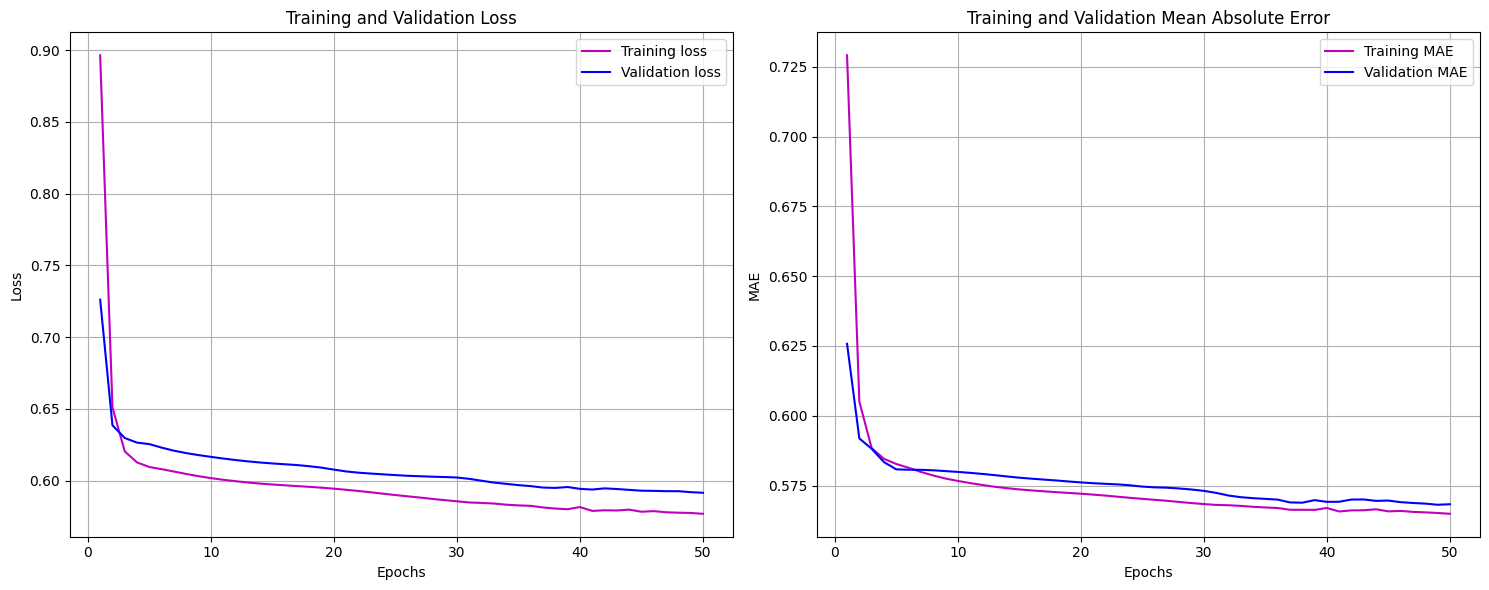

In [ ]:
import matplotlib.pyplot as plt

def plot_training_history(history):
    # Extract metrics from the history object
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    mae = history.history['mae']
    val_mae = history.history['val_mae']
    epochs = range(1, len(loss) + 1)

    # Create a figure with two subplots
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    # Plot training and validation loss
    axes[0].plot(epochs, loss, 'm', label='Training loss')
    axes[0].plot(epochs, val_loss, 'b', label='Validation loss')
    axes[0].set_title('Training and Validation Loss')
    axes[0].set_xlabel('Epochs')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True)

    # Plot training and validation MAE
    axes[1].plot(epochs, mae, 'm', label='Training MAE')
    axes[1].plot(epochs, val_mae, 'b', label='Validation MAE')
    axes[1].set_title('Training and Validation Mean Absolute Error')
    axes[1].set_xlabel('Epochs')
    axes[1].set_ylabel('MAE')
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
    plt.show()

# Call the function to plot the history
plot_training_history(history)

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Scale the test set inputs using the scalers fitted on the full dataset
#t_test_scaled = time_var_scaler.transform(t_test)
t_test_scaled = t_test
env_test_scaled = env_vars_scaler.transform(env_test)

# Make predictions on the scaled test inputs
predictions_scaled = model.predict((t_test_scaled, env_test_scaled))

# Inverse transform to get predictions and actuals back to original physical units
predictions = targets_scaler.inverse_transform(predictions_scaled)
Y_test_actual = targets_scaler.inverse_transform(y_test)

# Calculate final baseline metrics
rmse = np.sqrt(mean_squared_error(Y_test_actual, predictions))
r2 = r2_score(Y_test_actual, predictions)
mae = mean_absolute_error(Y_test_actual, predictions)

print(f"\n--- Evaluation Metrics ---")
print(f"Test RMSE: {rmse:.4f}")
print(f"Test R-squared: {r2:.4f}")
print(f"Test MAE: {mae:.4f}")

116/116 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step

--- Evaluation Metrics ---
Test RMSE: 82.5802
Test R-squared: -0.3912
Test MAE: 40.3588


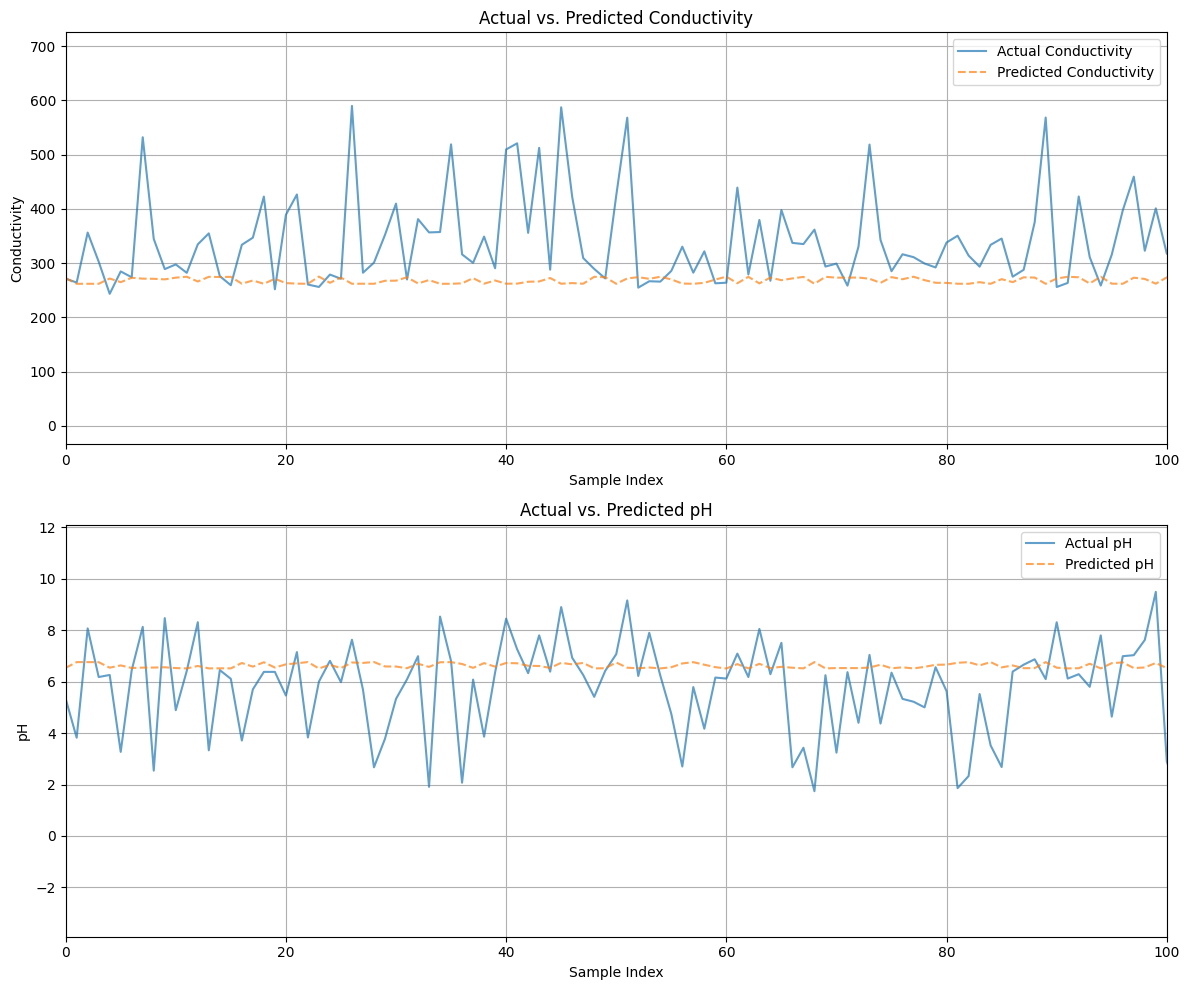

In [ ]:
import matplotlib.pyplot as plt

# Create a 2x1 figure for the plots
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# Plot for the first target (Conductivity)
axes[0].plot(Y_test_actual[:, 0], label='Actual Conductivity', alpha=0.7)
axes[0].plot(predictions[:, 0], label='Predicted Conductivity', alpha=0.7, linestyle='--')
axes[0].set_title('Actual vs. Predicted Conductivity')
axes[0].set_xlabel('Sample Index')
axes[0].set_ylabel('Conductivity')
axes[0].legend()
axes[0].grid(True)
axes[0].set_xlim(0, 100) # Zoom in on x-axis

# Plot for the second target (pH)
axes[1].plot(Y_test_actual[:, 1], label='Actual pH', alpha=0.7)
axes[1].plot(predictions[:, 1], label='Predicted pH', alpha=0.7, linestyle='--')
axes[1].set_title('Actual vs. Predicted pH')
axes[1].set_xlabel('Sample Index')
axes[1].set_ylabel('pH')
axes[1].legend()
axes[1].grid(True)
axes[1].set_xlim(0, 100) # Zoom in on x-axis

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()